# Flow-Sediment PINN 调试版

In [1]:
%load_ext autoreload
%autoreload 2
import importlib
import os
from datetime import datetime

import torch

from src.config import load_config
from src.data import (
    FVMeshPreprocessor,
    RealBoundaryConditionBuilder,
    load_real_case_data,
)
import src.plot as plot_module
importlib.reload(plot_module)

from src.model import FlowPINN, SedimentPINN
from src.physics import SVEsPhysicsLoss, SedimentPhysicsLoss
from src.plot import plot_dem_overview, visualize_results
from src.train import DecoupledTrainer
from src.utils import match_concentration, print_config_summary, save_training_outputs

torch.set_printoptions(precision=6, sci_mode=True)

## 1. 加载配置

In [2]:
config_path = "config.yaml"
cfg = load_config(config_path)

run_timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
output_dir = cfg.training.get('output_dir', 'outputs')
checkpoint_dir = cfg.training.get('checkpoint_dir', os.path.join(output_dir, 'checkpoints'))
os.makedirs(output_dir, exist_ok=True)

print('run_timestamp =', run_timestamp)
print_config_summary(cfg)

run_timestamp = 20260622-154705

[数据输入]
  DEM 路径: data/100ft.test1d.tif
  水沙过程线: data/FlowSedimentData.xlsx
  河道高程阈值(ft): 679
  入口方向: top
  出口方向: bottom

[时间控制]
  总模拟时间(s): 2937600.0
  训练采样间隔(s): 86400.0
  输出间隔(s): 86400.0
  是否包含非恒定项: True

[网格与尺度]
  边界高斯点数: 2
  典型水深(m): 10.0
  典型流速(m/s): 5.0

[水动力]
  重力加速度(m/s2): 9.81
  曼宁糙率: 0.01
  水动力自适应权重: True
  权重 EMA: 0.95
  权重下限: 0.2
  权重上限: 20.0

[泥沙输运]
  粒径组数: 10
  粒径组(mm): [0.177, 0.354, 0.707, 1.414, 2.828, 5.657, 11.31, 22.63, 45.25, 90.51]
  beta_default: 0.6
  epsilon_default: 0.1
  残差缩放: 1.0
  适应长度(m): 9.144
  颗粒密度(kg/m3): 2650.0
  水密度(kg/m3): 1000.0
  运动黏度(m2/s): 1e-06
  Wu 临界 Shields: 0.03
  skin shear factor: 1.0
  输沙能力权重: 1.0
  初始浓度权重: 5.0
  入口浓度权重: 1.0
  初始浓度: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

[床面形态]
  孔隙率: 0.4
  活动层厚度(m): 0.5
  床面变化输出尺度(m): 0.1
  床坡系数: 0.05
  床坡扩散权重: 1.0
  交换项权重: 1.0
  活动层系数: 10.0

[训练轮次与学习率]
  水动力 epoch: 1
  泥沙 epoch: 1
  联合 epoch: 1
  水动力学习率: 0.0005
  泥沙学习率: 0.0005
  泥沙 batch 单元数: 1024

[耦合与停止]

## 2. 读取真实数据与粒径组

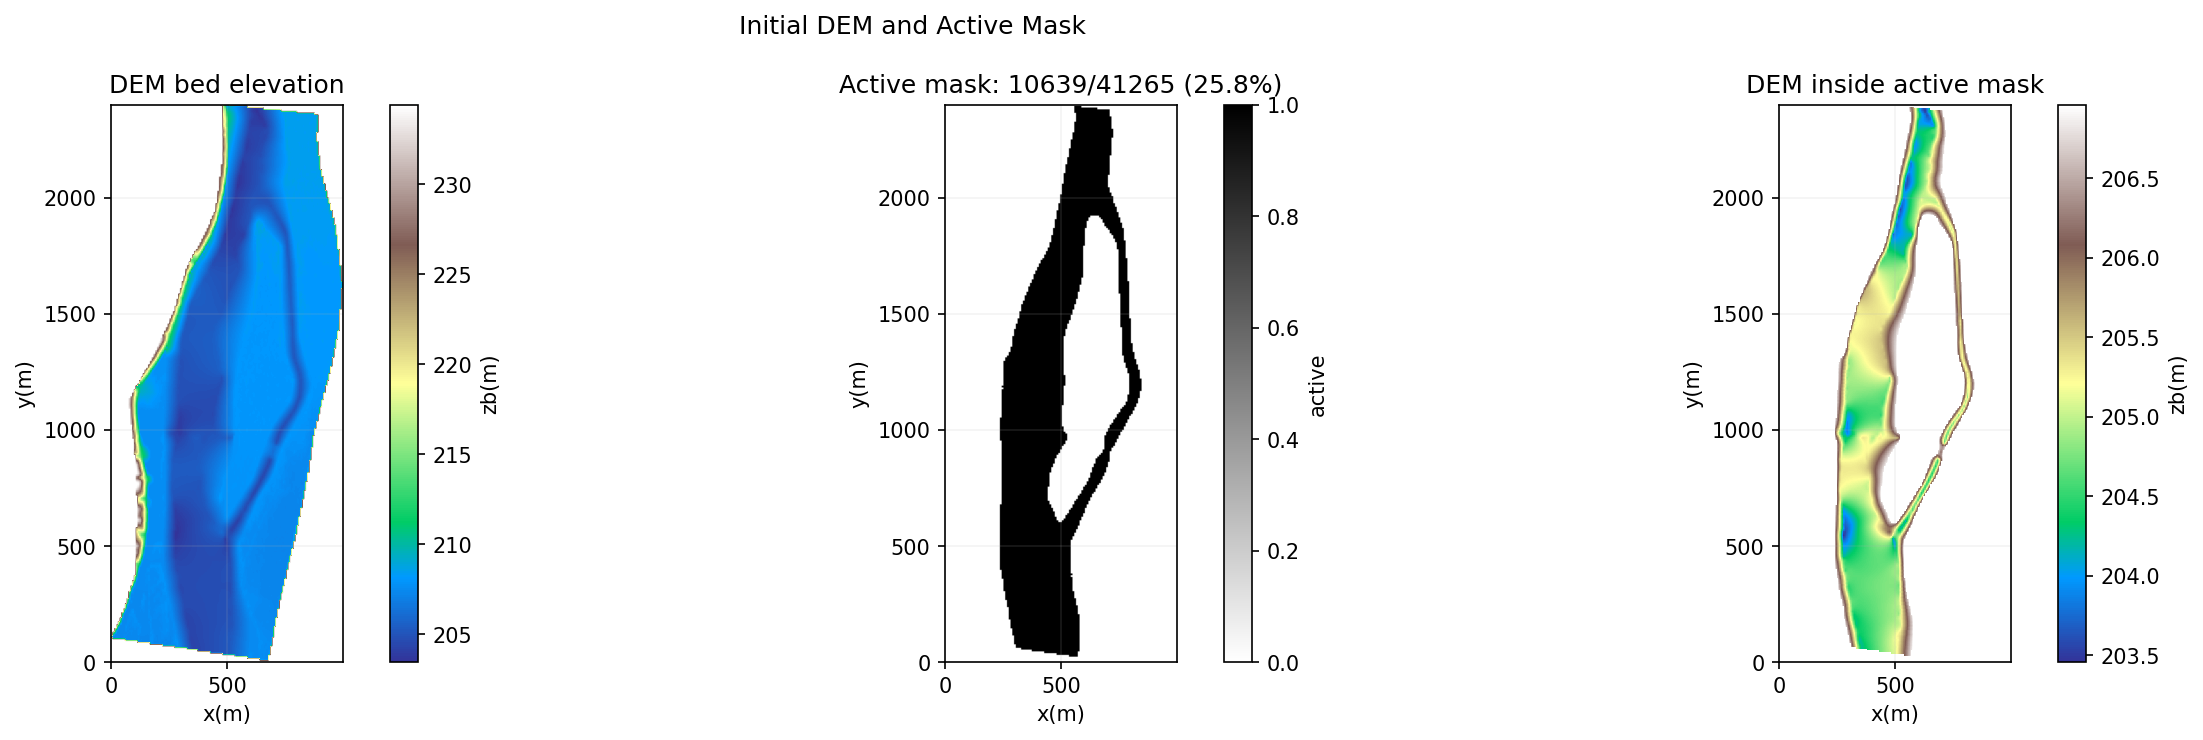

DEM: 131x315, resolution=7.620m, active_cells=10639
Hydrograph: Q=35 points, stage=35 points, gradation=10 classes
config grain_diameters = [0.000177, 0.000354, 0.000707, 0.001414, 0.002828, 0.005657, 0.01131, 0.02263, 0.04525, 0.09051]
real_case grain_diameters = [0.0002500000118743628, 0.0005000000237487257, 0.0010000000474974513, 0.0020000000949949026, 0.004000000189989805, 0.00800000037997961, 0.01600000075995922, 0.03200000151991844, 0.06400000303983688, 0.12800000607967377]
used grain_diameters = [0.000177, 0.000354, 0.000707, 0.001414, 0.002828, 0.005657, 0.01131, 0.02263, 0.04525, 0.09051]
initial grain_fractions = [0.05000000074505806, 0.05000000074505806, 0.10000000149011612, 0.10000000894069672, 0.19999998807907104, 0.19999998807907104, 0.10000002384185791, 0.09999996423721313, 0.050000011920928955, 0.050000011920928955]


In [3]:
real_case = load_real_case_data(cfg.data)
plot_dem_overview(real_case.bed_grid, real_case.active_mask, real_case.resolution)  # 可视化 DEM 和活动单元，辅助调试
# 粒径组可以由 config.yaml 显式指定；若留空，则直接使用 Excel 中 MainChannel 级配。
grain_diameters = cfg.grain_diameters
if not grain_diameters:
    grain_diameters = real_case.grain_diameters

print(
    f"DEM: {real_case.bed_grid.shape[1]}x{real_case.bed_grid.shape[0]}, "
    f"resolution={real_case.resolution:.3f}m, active_cells={int(real_case.active_mask.sum())}"
)
print(
    f"Hydrograph: Q={len(real_case.flow_times)} points, "
    f"stage={len(real_case.stage_times)} points, "
    f"gradation={len(real_case.grain_diameters)} classes"
)
print('config grain_diameters =', cfg.grain_diameters)
print('real_case grain_diameters =', real_case.grain_diameters)
print('used grain_diameters =', grain_diameters)
print('initial grain_fractions =', real_case.grain_fractions)

## 3. 构建 FVM 网格

In [4]:
mesh = FVMeshPreprocessor(
    real_case.bbox,
    real_case.resolution,
    initial_bed=real_case.bed_grid,
    n_gauss_points=cfg.n_gauss_points,
    active_mask=real_case.active_mask,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print('mesh cells =', mesh.n_cells)
print('active cells =', int(mesh.active_cell_mask.sum()))
print('bbox =', real_case.bbox)
print('bounds =', real_case.bounds)

Using device: cpu
mesh cells = 41265
active cells = 10639
bbox = {'xmin': 0.0, 'xmax': 998.22, 'ymin': 0.0, 'ymax': 2400.3}
bounds = {'x_min': 0.0, 'x_max': 998.22, 'y_min': 0.0, 'y_max': 2400.3}


## 4. 创建水动力与泥沙模型

In [5]:
flow_model = FlowPINN(
    input_dim=3, 
    hidden_dim=64, 
    num_block=4, 
    output_dim=3
).to(device)

n_grains = len(grain_diameters)
# 初始泥沙浓度
initial_concentration = match_concentration(cfg.initial_sediment_concentration, n_grains)
sediment_model = SedimentPINN(
    input_dim=3,
    hidden_dim=64,
    num_block=4,
    output_dim=n_grains * 2,  # C_tk 和 dzb_k
    n_concentration_outputs=n_grains,
    initial_concentration=initial_concentration,
    bed_change_scale=cfg.bed_change_scale,
).to(device)

print('n_grains =', n_grains)
print('initial_concentration =', initial_concentration)
print('flow params =', sum(p.numel() for p in flow_model.parameters()))
print('sediment params =', sum(p.numel() for p in sediment_model.parameters()))

n_grains = 10
initial_concentration = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
flow params = 35715
sediment params = 36276


## 5. 创建物理损失函数

In [6]:
flow_loss_fn = SVEsPhysicsLoss(
    fvm_mesh=mesh,
    g=cfg.g,
    n_manning=cfg.n_manning,
    bounds=real_case.bounds,
    typical_depth=cfg.typical_depth,
    typical_velocity=cfg.typical_velocity,
    simulation_time=cfg.simulation_time,
    include_time_terms=cfg.include_time_terms,
    adaptive_weighting=cfg.adaptive_flow_weighting, # 是否启动自适应权重调整
    adaptive_weight_ema_decay=cfg.flow_weight_ema_decay,  # EMA 衰减率，控制权重更新的平滑程度
    adaptive_weight_min=cfg.flow_weight_min,
    adaptive_weight_max=cfg.flow_weight_max,
)

sediment_loss_fn = SedimentPhysicsLoss(
    fvm_mesh=mesh,
    bounds=real_case.bounds,
    include_time_terms=cfg.include_time_terms,
    grain_diameters=grain_diameters,
    beta_default=cfg.beta_default,
    epsilon_default=cfg.epsilon_default,
    residual_scale=cfg.sediment_residual_scale,
    adaptation_length=cfg.adaptation_length,
    rho_s=cfg.rho_s,
    rho_w=cfg.rho_w,
    g=cfg.g,
    n_manning=cfg.n_manning,
    kinematic_viscosity=cfg.kinematic_viscosity,
    wu_theta_cr=cfg.wu_theta_cr,
    skin_shear_factor=cfg.skin_shear_factor,
    alpha_active_layer=cfg.alpha_active_layer,
    w_capacity=cfg.w_capacity,
    w_initial_sediment=cfg.w_initial_sediment,
    initial_sediment_concentration=initial_concentration,
    w_inlet_sediment=cfg.w_inlet_sediment,
    w_bed_change=cfg.training.get('w_bed_change', 1.0),
    porosity=cfg.porosity,
    bed_slope_coefficient=cfg.bed_slope_coefficient,
    bed_slope_diffusion_weight=cfg.bed_slope_diffusion_weight,
    exchange_weight=cfg.exchange_weight,
    source_sharpness=cfg.source_sharpness,
    simulation_time=cfg.simulation_time,
    typical_depth=cfg.typical_depth,
    typical_velocity=cfg.typical_velocity,
)

print('flow_loss_fn ready')
print('sediment_loss_fn ready')

flow_loss_fn ready
sediment_loss_fn ready


## 6. 创建训练器和真实边界条件

In [7]:
trainer = DecoupledTrainer(
    fvm_mesh=mesh,
    device=device,
    flow_model=flow_model,
    sediment_model=sediment_model,
    flow_loss_fn=flow_loss_fn,
    sediment_loss_fn=sediment_loss_fn,
    simulation_time=cfg.simulation_time,
    initial_gradation=real_case.grain_fractions,
    active_layer_thickness=cfg.active_layer_thickness,
    flow_lr=cfg.training.get('flow_lr', 1e-4),
    transport_lr=cfg.training.get('transport_lr', 1e-4),
    sediment_cell_batch_size=cfg.training.get('sediment_cell_batch_size', 1024),
    flow_loss_tol=cfg.training.get('flow_loss_tol', 0.0),
    sediment_loss_tol=cfg.training.get('sediment_loss_tol', 0.0),
    joint_loss_tol=cfg.training.get('joint_loss_tol', 0.0),
    early_stop_patience=cfg.training.get('early_stop_patience', 0),
    early_stop_min_delta=cfg.training.get('early_stop_min_delta', 0.0),
    coupling_iterations=cfg.training.get('coupling_iterations', 5),
    coupling_relaxation=cfg.training.get('coupling_relaxation', 0.3),
    coupling_bed_tol=cfg.training.get('coupling_bed_tol', 1.0e-5),
    flow_boundary_weight=cfg.training.get('flow_boundary_weight', 0.5),
    adaptive_boundary_weighting=cfg.training.get('adaptive_boundary_weighting', True),
    boundary_weight_ema_decay=cfg.training.get('boundary_weight_ema_decay', 0.95),
    boundary_weight_min=cfg.training.get('boundary_weight_min', 1.0e-4),
    boundary_weight_max=cfg.training.get('boundary_weight_max', 1.0),
    run_timestamp=run_timestamp,
    checkpoint_dir=checkpoint_dir,
)

bc_builder = RealBoundaryConditionBuilder(
    mesh=mesh,
    real_case=real_case,
    typical_depth=cfg.typical_depth,
    typical_velocity=cfg.typical_velocity,
    simulation_time=cfg.simulation_time,
)

print('trainer ready')
print('training settings:', cfg.training)

trainer ready
training settings: TrainingConfig(values={'flow_epochs': 1, 'sediment_epochs': 1, 'joint_epochs': 1, 'coupling_iterations': 5, 'coupling_relaxation': 0.25, 'coupling_bed_tol': 1e-05, 'flow_boundary_weight': 0.5, 'adaptive_boundary_weighting': True, 'boundary_weight_ema_decay': 0.95, 'boundary_weight_min': 0.0001, 'boundary_weight_max': 1.0, 'flow_loss_tol': 0.0, 'sediment_loss_tol': 0.0, 'joint_loss_tol': 0.0, 'early_stop_patience': 30, 'early_stop_min_delta': 0, 'sediment_cell_batch_size': 1024, 'flow_lr': 0.0005, 'transport_lr': 0.0005, 'w_bed_change': 1.0, 'output_dir': 'outputs', 'checkpoint_dir': 'outputs/checkpoints'})


## 7. 运行三阶段训练

长训练会从这个单元开始。

In [8]:
bed_history = trainer.run_training(
    simulation_time=cfg.simulation_time,
    sample_dt=cfg.sample_dt,
    output_dt=cfg.output_dt,
    flow_epochs=cfg.training['flow_epochs'],
    sediment_epochs=cfg.training['sediment_epochs'],
    bc_builder=bc_builder,
    joint_epochs=cfg.training['joint_epochs'],
)

print('bed_history length =', len(bed_history))
print('history keys =', sorted(trainer.history.keys()))


阶段 1/3: 训练水动力 PINN，时间点数=35
Flow PINN [############################] 35/35 100.0% elapsed=  35.8s eta=   0.0s loss=7.122e-04  checkpoint saved: outputs/checkpoints/best_phase1_flow_20260622-154705.pt
Flow PINN [############################] 35/35 100.0% elapsed=  35.8s eta=   0.0s loss=7.122e-04
阶段 1 完成: Flow Loss=7.12e-04

阶段 2/3: 冻结水动力，训练泥沙 PINN 和分粒径累计床变 Δzb_k
  checkpoint saved: outputs/checkpoints/phase1_flow_20260622-154705.pt
Sediment PINN [############################] 385/385 100.0% elapsed= 415.2s eta=   0.0s loss=8.790e-12  checkpoint saved: outputs/checkpoints/best_phase2_sediment_20260622-154705.pt
Sediment PINN [############################] 385/385 100.0% elapsed= 415.2s eta=   0.0s loss=8.790e-12
阶段 2 完成: Sediment Loss=8.79e-12

阶段 3/3: 联合优化水动力 PINN 和泥沙 PINN
  checkpoint saved: outputs/checkpoints/phase2_sediment_20260622-154705.pt

耦合迭代 1/5: bed_error=8.997e-06m, joint_epochs=1
Joint PINN [############################] 420/420 100.0% elapsed= 430.9s eta=   0.0s loss=6.2

## 8. 保存训练产物

In [9]:
save_training_outputs(
    output_dir=output_dir,
    config_path=config_path,
    flow_model=flow_model,
    sediment_model=sediment_model,
    trainer=trainer,
    bed_history=bed_history,
    run_timestamp=run_timestamp,
)

分时刻床面结果已保存到: outputs/time_points_20260622-154705
训练结果已保存到: outputs


## 9. 绘图

In [10]:
visualize_results(
    mesh=mesh,
    bed_history=bed_history,
    bbox=real_case.bbox,
    resolution=real_case.resolution,
    history=trainer.history,
    simulation_time=cfg.simulation_time,
    case_name='real',
    output_dir=output_dir,
    run_timestamp=run_timestamp,
)


✓ outputs/real_bed_20260622-154705.png
✓ outputs/real_profiles_20260622-154705.png
✓ outputs/real_losses_20260622-154705.png
✓ outputs/real_phase1_flow_losses_20260622-154705.png
✓ outputs/real_phase2_sediment_losses_20260622-154705.png
✓ outputs/real_phase3_joint_losses_20260622-154705.png
✓ outputs/real_flow_weights_20260622-154705.png

  Initial river peak: 206.9592m  Final river peak: 206.9592m
  Peak change: +0.0000m (0.0%)
